In [1]:
# Stage 1: Data Understanding
# Understanding the dataset structure and available information.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("traffic.csv")

In [3]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [5]:
df.describe(include='all')

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


In [6]:
# Stage 2: Data Cleaning
# Checking for missing values and duplicate records.

In [7]:
df.isnull().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(103711)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
# Stage 3: Event Analysis
# Analyzing the distribution of user actions.

In [11]:
event_counts = df['event'].value_counts()

event_counts

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64

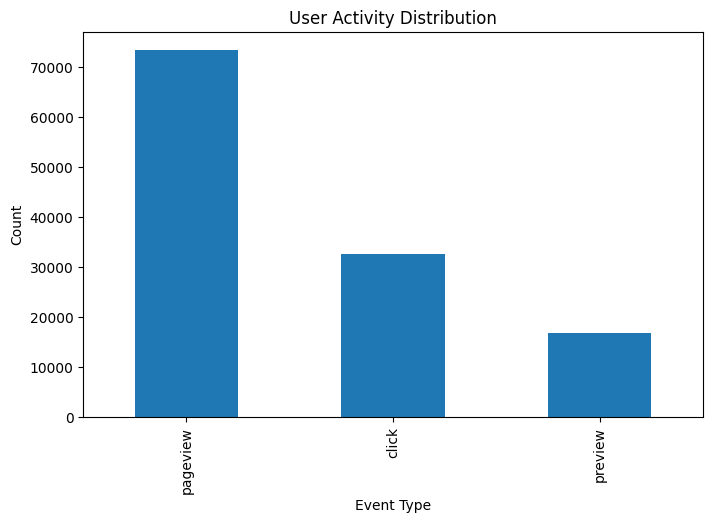

In [12]:
plt.figure(figsize=(8,5))

event_counts.plot(kind='bar')

plt.title("User Activity Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

In [13]:
# Stage 4: Traffic Source Analysis
# Identifying the most popular traffic sources using link IDs.

In [14]:
top_sources = df['linkid'].value_counts().head(10)

top_sources

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    8288
e849515b-929d-44c8-a505-e7622f1827e9    3950
522da5cc-8177-4140-97a7-a84fdb4caf1c    3786
a82e72d8-523f-43ab-9fd0-992605d54b4e    3059
681d888a-59ce-4acb-b7c5-95dab0c063d9    2865
23199824-9cf5-4b98-942a-34965c3b0cc2    2675
c2c876ab-b093-4750-9449-6b4913da6af3    2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd    2390
d5317591-872a-487d-87cb-10a516643d5f    2074
a107c329-5d35-4c7d-8050-50bc69ce7dbc    2072
Name: count, dtype: int64

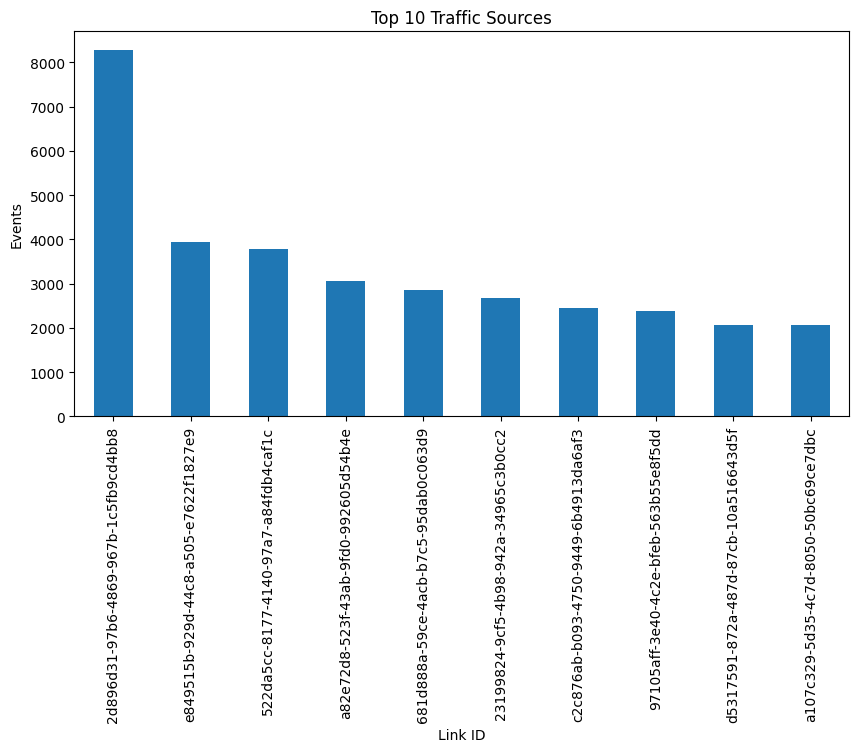

In [15]:
plt.figure(figsize=(10,5))

top_sources.plot(kind='bar')

plt.title("Top 10 Traffic Sources")
plt.xlabel("Link ID")
plt.ylabel("Events")

plt.show()

In [16]:
# Stage 5: Geographic Analysis
# Understanding where users are coming from.

In [17]:
top_countries = df['country'].value_counts().head(10)

top_countries

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64

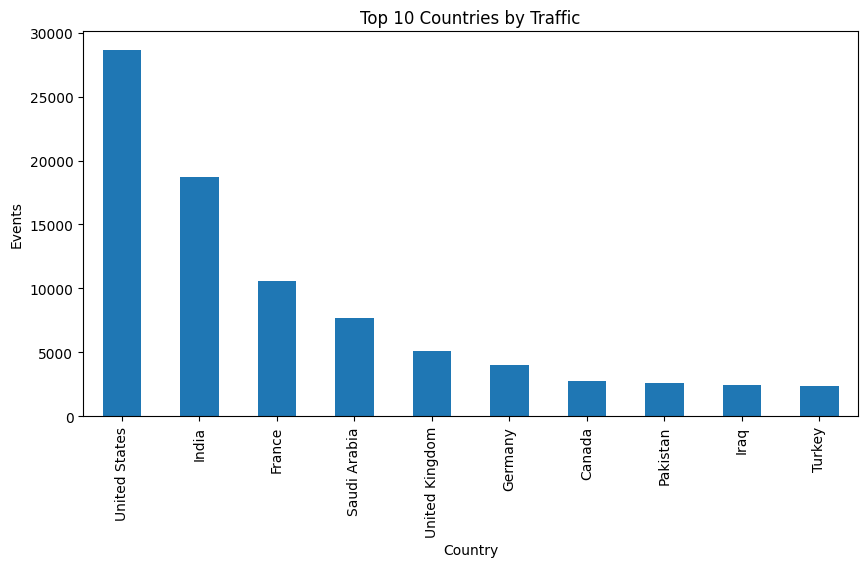

In [18]:
plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Traffic")
plt.xlabel("Country")
plt.ylabel("Events")

plt.show()

In [19]:
# Stage 6: User Journey Funnel
# Analyzing how users move through the interaction process.

In [20]:
funnel = df['event'].value_counts()

funnel

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64

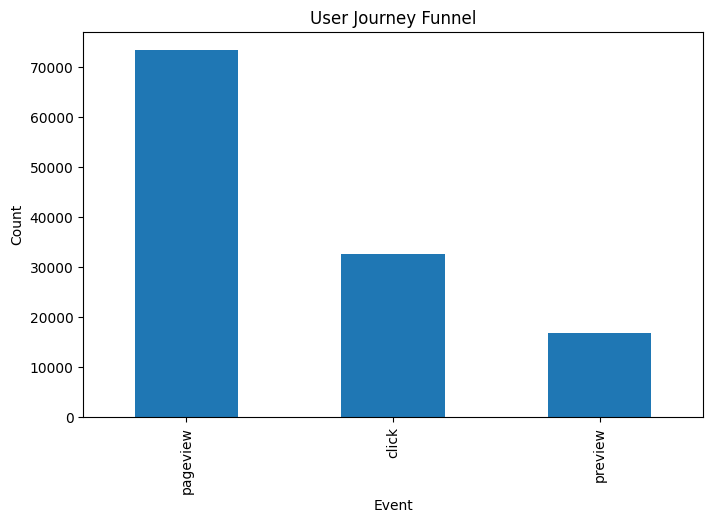

In [21]:
plt.figure(figsize=(8,5))

funnel.plot(kind='bar')

plt.title("User Journey Funnel")
plt.xlabel("Event")
plt.ylabel("Count")

plt.show()

In [22]:
# Key Findings
# 1. Pageviews were the most common user activity, with 73,360 events recorded. Clicks (32,499) and previews (16,708) were much lower, 
#    showing that while many users visit the website, fewer interact further with the content.
# 2. A small number of link IDs generated a large portion of the overall traffic. This suggests that certain links or campaigns are significantly 
#    more effective at attracting users than others.
# 3. The United States and India were the top traffic-generating countries, contributing the highest number of interactions. 
#    This indicates that the website has a strong audience presence in these regions.
# 4. User engagement decreases throughout the interaction funnel, moving from pageviews to previews and then to clicks. 
#    This suggests that some users lose interest before taking the final action.
# 5. Traffic is concentrated among a few key countries and links, showing that website performance depends heavily on a limited number of traffic sources 
#    and audience locations.

In [23]:
# Recommendations
# 1. Improve the top-performing links to get more clicks and engagement.
# 2. Make call-to-action buttons more visible to encourage user interaction.
# 3. Focus marketing efforts on the United States and India.
# 4. Analyze successful links and apply similar strategies to weaker ones.
# 5. Work on reducing the drop-off between pageviews and clicks.